# 11 - EDA: Sentiment & Category Analysis (Production Dataset)
## ShopEase Europe | Sentiment Analysis Project - Phase 2
**Objective:** Explore sentiment patterns across product categories 
and over time to identify which categories drive dissatisfaction and 
whether sentiment trends have shifted across the dataset's 17-year span.

## Import Libaries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## Load the Dataset

In [6]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
PROCESSED_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'production_preprocessed_reviews.csv')
FIGURES_PATH = os.path.join(PROJECT_ROOT, 'reports', 'figures')

df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded: 21,055 rows x 11 columns
Columns: ['review_id', 'cleaned_review', 'preprocessed_text', 'sentiment', 'country', 'product_category', 'year', 'month', 'rating', 'review_length', 'word_count']


## Sentiment Distribution by Category

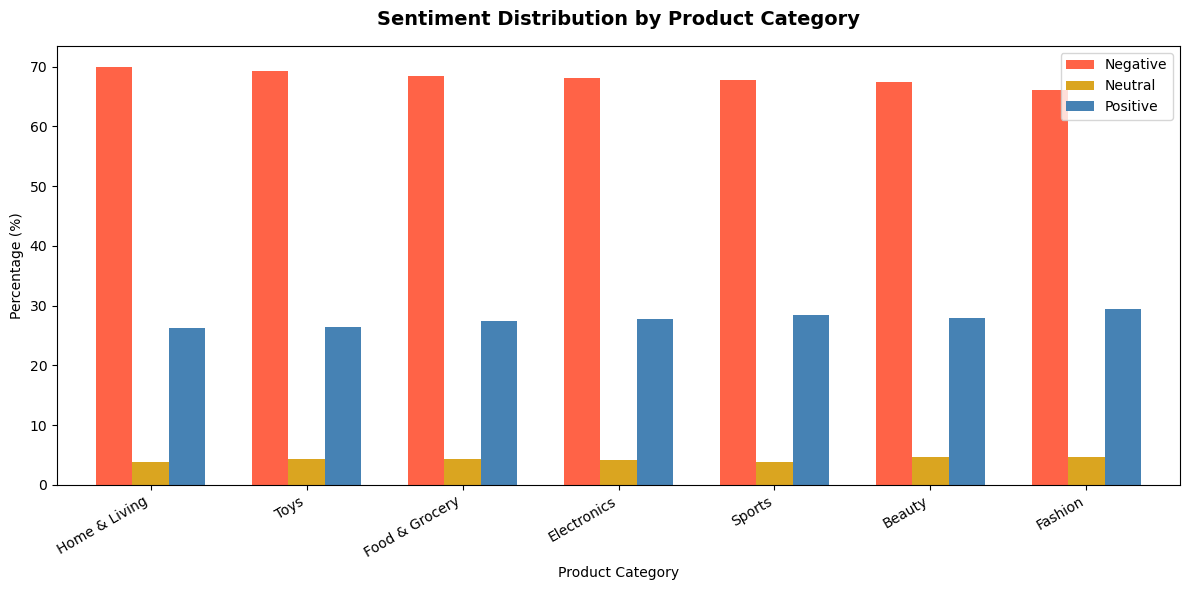

In [7]:
category_sentiment = df.groupby(['product_category', 'sentiment']).size().unstack(fill_value=0)
category_sentiment_pct = category_sentiment.div(category_sentiment.sum(axis=1), axis=0) * 100
category_sentiment_pct = category_sentiment_pct.round(2)
category_sentiment_pct = category_sentiment_pct.sort_values('negative', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
category_sentiment_pct.plot(kind='bar', ax=ax, color=['tomato', 'goldenrod', 'steelblue'], width=0.7)
ax.set_title('Sentiment Distribution by Product Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product Category')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(['Negative', 'Neutral', 'Positive'], loc='upper right')
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'production_sentiment_by_category.png'), dpi=150, bbox_inches='tight')
plt.show()

## Sentiment by Category Finding

Negative sentiment dominates across all seven product categories, 
ranging from 66.2% in Fashion to 70.1% in Home & Living. Fashion 
stands out with the lowest negative rate and highest positive rate 
at nearly 30%, while Home & Living shows the most dissatisfaction.

**Insight:** The consistently high negative sentiment across every 
category suggests the underlying driver of dissatisfaction is likely 
related to broader service factors such as delivery, account issues, 
or customer support, rather than anything specific to individual 
product types. This points toward ShopEase Europe's operational and 
service experience as the priority area for improvement, rather than 
product quality within any single category.